Design and implement a Multilayer Perceptron (MLP) for classification of the Iris or Wine dataset, and evaluate its performance using accuracy and a confusion matrix.

In [1]:
# Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [2]:
# Load the Iris dataset

iris = load_iris()

X = iris.data
y = iris.target

print("Dataset loaded successfully.")
print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Dataset loaded successfully.
Features Shape: (150, 4)
Target Shape: (150,)


In [3]:
# Display dataset information

print("Feature Names:")
print(iris.feature_names)

print("\nTarget Names:")
print(iris.target_names)

print("\nFirst 5 Samples:")
print(X[:5])

Feature Names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Target Names:
['setosa' 'versicolor' 'virginica']

First 5 Samples:
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]


In [4]:
# Create a pandas DataFrame

df = pd.DataFrame(
    X,
    columns=iris.feature_names
)

df["target"] = y

print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  


In [5]:
# Check missing values and class distribution

print("Missing Values:")
print(df.isnull().sum())

print("\nClass Distribution:")
print(df["target"].value_counts())

Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64

Class Distribution:
target
0    50
1    50
2    50
Name: count, dtype: int64


In [6]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples:", X_train.shape[0])
print("Testing Samples :", X_test.shape[0])

Training Samples: 120
Testing Samples : 30


In [7]:
# Standardize input features

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


In [8]:
# Build the Multilayer Perceptron model

mlp_model = MLPClassifier(
    hidden_layer_sizes=(10, 10),
    activation="relu",
    solver="adam",
    max_iter=500,
    random_state=42
)

print("MLP model created.")

MLP model created.


In [9]:
# Train the MLP model

mlp_model.fit(
    X_train,
    y_train
)

print("MLP model trained successfully.")

MLP model trained successfully.


/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [10]:
# Generate predictions on test data

y_pred = mlp_model.predict(X_test)

print("Predicted Labels:")
print(y_pred)

Predicted Labels:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 2 1 0 2 0]


In [11]:
# Calculate classification accuracy

accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    "MLP Test Accuracy:",
    f"{accuracy * 100:.2f}%"
)

MLP Test Accuracy: 96.67%


In [12]:
# Generate classification report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=iris.target_names
    )
)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [13]:
# Generate confusion matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


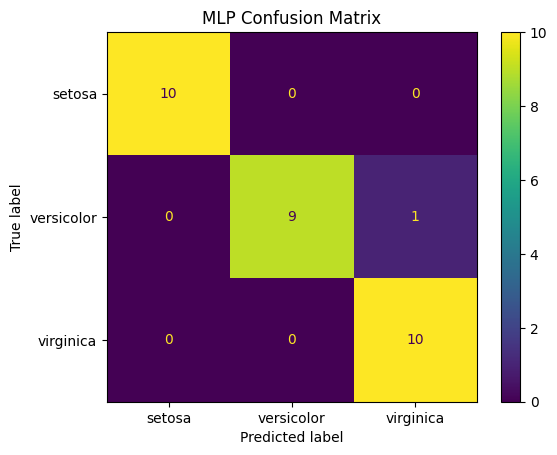

In [14]:
# Display confusion matrix

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
)

display.plot()

plt.title("MLP Confusion Matrix")
plt.show()

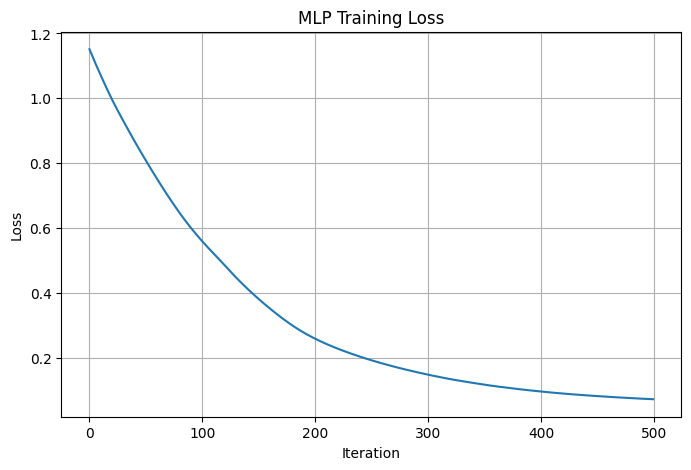

In [15]:
# Plot MLP training loss

plt.figure(figsize=(8, 5))

plt.plot(
    mlp_model.loss_curve_
)

plt.title("MLP Training Loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")

plt.grid(True)
plt.show()

In [16]:
# Test a few individual samples

sample_predictions = mlp_model.predict(
    X_test[:5]
)

for i in range(5):

    actual = iris.target_names[y_test[i]]
    predicted = iris.target_names[sample_predictions[i]]

    print(
        f"Sample {i + 1}: "
        f"Actual = {actual}, "
        f"Predicted = {predicted}"
    )

Sample 1: Actual = setosa, Predicted = setosa
Sample 2: Actual = virginica, Predicted = virginica
Sample 3: Actual = versicolor, Predicted = versicolor
Sample 4: Actual = versicolor, Predicted = versicolor
Sample 5: Actual = setosa, Predicted = setosa


In [17]:
# Display final results

print("=" * 40)
print("MLP CLASSIFICATION RESULTS")
print("=" * 40)

print("Dataset : Iris")
print("Model   : Multilayer Perceptron")
print(f"Accuracy: {accuracy * 100:.2f}%")

print("\nConfusion Matrix:")
print(cm)

print("=" * 40)

MLP CLASSIFICATION RESULTS
Dataset : Iris
Model   : Multilayer Perceptron
Accuracy: 96.67%

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]
